# AIGFS

In December 2025, NOAA announced the release of three AI global forecasting systems.

[NOAA deploys new generation of AI-driven global weather models](https://www.noaa.gov/news-release/noaa-deploys-new-generation-of-ai-driven-global-weather-models)

All three models are available for download in Herbie:

- `model="aigfs"`

- `model="aigefs"`

- `model="hgefs"`

This notebook demonstrates how to download and use AIGFS data using Herbie.


In [1]:
from herbie import Herbie
from herbie.toolbox import EasyMap, pc, ccrs
from herbie import paint

import matplotlib.pyplot as plt

There are two available products: 

- `product="sfc"`
- `product="pres"`

In [2]:
H = Herbie("2026-02-01", model="aigfs", product="sfc")
H

✅ Found ┊ model=aigfs ┊ product=sfc ┊ 2026-Feb-01 00:00 UTC F00 ┊ GRIB2 @ nomads ┊ IDX @ local


▌▌Herbie AIGFS model sfc product initialized 2026-Feb-01 00:00 UTC F00 ┊ source=nomads

In [3]:
# Show all available sources
H.SOURCES

{'nomads': 'https://nomads.ncep.noaa.gov/pub/data/nccf/com/aigfs/prod/aigfs.20260201/00/model/atmos/grib2/aigfs.t00z.sfc.f000.grib2'}

In [4]:
H.inventory()

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,1002703.0,0-1002703,2026-02-01,2026-02-01,UGRD,10 m above ground,anl,:UGRD:10 m above ground:anl:
1,2,1002704,1981711.0,1002704-1981711,2026-02-01,2026-02-01,VGRD,10 m above ground,anl,:VGRD:10 m above ground:anl:
2,3,1981712,2512347.0,1981712-2512347,2026-02-01,2026-02-01,TMP,2 m above ground,anl,:TMP:2 m above ground:anl:
3,4,2512348,NaN,2512348-,2026-02-01,2026-02-01,PRMSL,mean sea level,anl,:PRMSL:mean sea level:anl:


In [5]:
H = Herbie("2026-02-01", model="aigfs", product="pres")
H.inventory()


✅ Found ┊ model=aigfs ┊ product=pres ┊ 2026-Feb-01 00:00 UTC F00 ┊ GRIB2 @ nomads ┊ IDX @ local


,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
0,1,0,673222.0,0-673222,2026-02-01,2026-02-01,HGT,50 mb,anl,:HGT:50 mb:anl:
1,2,673223,1329174.0,673223-1329174,2026-02-01,2026-02-01,HGT,100 mb,anl,:HGT:100 mb:anl:
2,3,1329175,1993554.0,1329175-1993554,2026-02-01,2026-02-01,HGT,150 mb,anl,:HGT:150 mb:anl:
3,4,1993555,2656655.0,1993555-2656655,2026-02-01,2026-02-01,HGT,200 mb,anl,:HGT:200 mb:anl:
4,5,2656656,3314383.0,2656656-3314383,2026-02-01,2026-02-01,HGT,250 mb,anl,:HGT:250 mb:anl:
...,...,...,...,...,...,...,...,...,...,...
73,74,77577252,78369407.0,77577252-78369407,2026-02-01,2026-02-01,VVEL,600 mb,anl,:VVEL:600 mb:anl:
74,75,78369408,79179487.0,78369408-79179487,2026-02-01,2026-02-01,VVEL,700 mb,anl,:VVEL:700 mb:anl:
75,76,79179488,80019147.0,79179488-80019147,2026-02-01,2026-02-01,VVEL,850 mb,anl,:VVEL:850 mb:anl:
76,77,80019148,80844486.0,80019148-80844486,2026-02-01,2026-02-01,VVEL,925 mb,anl,:VVEL:925 mb:anl:


In [6]:
ds = H.xarray(":TMP:700 mb")

Text(0.0, 1.0, 'AIGFS: pressure fields, 0.25 degree resolution')

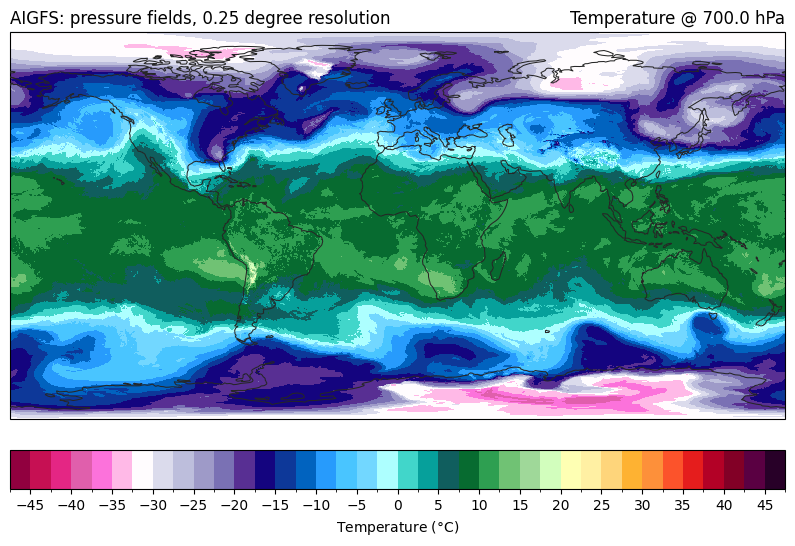

In [7]:
ax = EasyMap(crs=ds.herbie.crs, figsize=[10, 8]).ax
p = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.t - 273.15,
    transform=pc,
    **paint.NWSTemperature.kwargs2,
)
plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05, **paint.NWSTemperature.cbar_kwargs2
)

ax.set_title(f"{ds.t.GRIB_name} @ {ds.t.isobaricInhPa.item()} hPa", loc="right")
ax.set_title(f"{ds.model.upper()}: {H.product_description}", loc="left")

Now, going back to the surface product, just for fun, let's plot the change in 24-hr sea level pressure

✅ Found ┊ model=aigfs ┊ product=sfc ┊ 2026-Feb-01 00:00 UTC F00 ┊ GRIB2 @ nomads ┊ IDX @ local
✅ Found ┊ model=aigfs ┊ product=sfc ┊ 2026-Feb-01 00:00 UTC F24 ┊ GRIB2 @ nomads ┊ IDX @ local


Text(0.5, 1.0, 'Change in Sea Level Pressure; F24 minus F00')

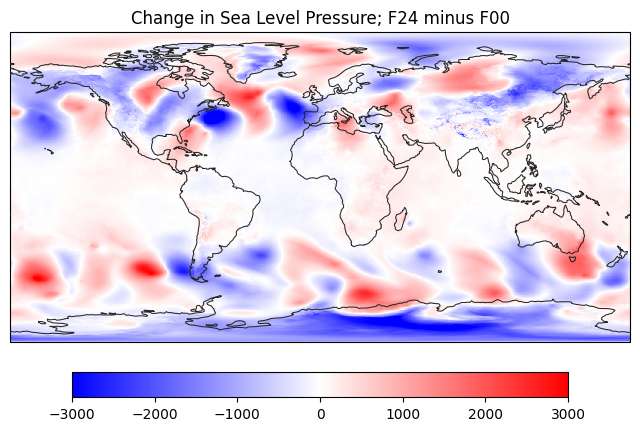

In [8]:
H1 = Herbie("2026-02-01", model="aigfs", product="sfc", fxx=0)
H2 = Herbie("2026-02-01", model="aigfs", product="sfc", fxx=24)

diff = H2.xarray("PRMSL").prmsl - H1.xarray("PRMSL").prmsl

ax = EasyMap(figsize=[8, 8]).ax
p = ax.pcolormesh(
    diff.longitude, diff.latitude, diff, transform=pc, vmax=3000, vmin=-3000, cmap="bwr"
)

plt.colorbar(
    p,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    shrink=0.8,
)

plt.title("Change in Sea Level Pressure; F24 minus F00")